# Task 1: Linear Regression — California Housing Price Predictor
**Objective:** Train and evaluate a Linear Regression model to predict median house values  
**Dataset:** California Housing (sklearn-compatible, 20,640 samples, 8 features)  
**Deliverables:** EDA, model training, evaluation metrics (MAE, RMSE, R²), plots, saved model


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pickle

## 2. Load Dataset

In [ ]:
housing = fetch_california_housing(as_frame=True)
df = pd.concat([housing.data,housing.target.rename("MedHouseVal")],axis=1)
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0000,6.9841,1.0238,322.0000,2.5556,37.8800,-122.2300,4.5260
1,8.3014,21.0000,6.2381,0.9719,2401.0000,2.1098,37.8600,-122.2200,3.5850
2,7.2574,52.0000,8.2881,1.0734,496.0000,2.8023,37.8500,-122.2400,3.5210
3,5.6431,52.0000,5.8174,1.0731,558.0000,2.5479,37.8500,-122.2500,3.4130
4,3.8462,52.0000,6.2819,1.0811,565.0000,2.1815,37.8500,-122.2500,3.4220


## 3. Exploratory Data Analysis (EDA)
### 3.1 Basic Statistics

In [8]:
print("Dataset Shape:", df.shape)
df.info()
print("\nStatistical Summary:")
df.describe()

Dataset Shape: (20640, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB

Statistical Summary:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.0000,20640.0000,20640.0000,20640.0000,20640.0000,20640.0000,20640.0000,20640.0000,20640.0000
mean,3.8707,28.6395,5.4290,1.0967,1425.4767,3.0707,35.6319,-119.5697,2.0686
std,1.8998,12.5856,2.4742,0.4739,1132.4621,10.3860,2.1360,2.0035,1.1540
min,0.4999,1.0000,0.8462,0.3333,3.0000,0.6923,32.5400,-124.3500,0.1500
25%,2.5634,18.0000,4.4407,1.0061,787.0000,2.4297,33.9300,-121.8000,1.1960
50%,3.5348,29.0000,5.2291,1.0488,1166.0000,2.8181,34.2600,-118.4900,1.7970
75%,4.7432,37.0000,6.0524,1.0995,1725.0000,3.2823,37.7100,-118.0100,2.6472
max,15.0001,52.0000,141.9091,34.0667,35682.0000,1243.3333,41.9500,-114.3100,5.0000


### 3.2 Missing Values Check

In [9]:
# Check for missing values
missing = df.isnull().sum()
print("Missing Values per Column:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values ✓")


Missing Values per Column:
No missing values ✓


### 3.3 Target Distribution & Key Feature Scatter

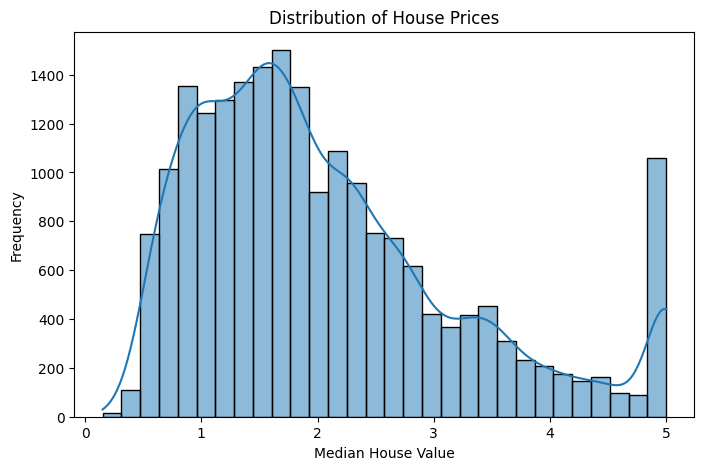

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(df["MedHouseVal"],kde=True,bins=30)
plt.title("Distribution of House Prices")
plt.xlabel("Median House Value")
plt.ylabel("Frequency")
plt.show()

### 3.4 Correlation Heatmap

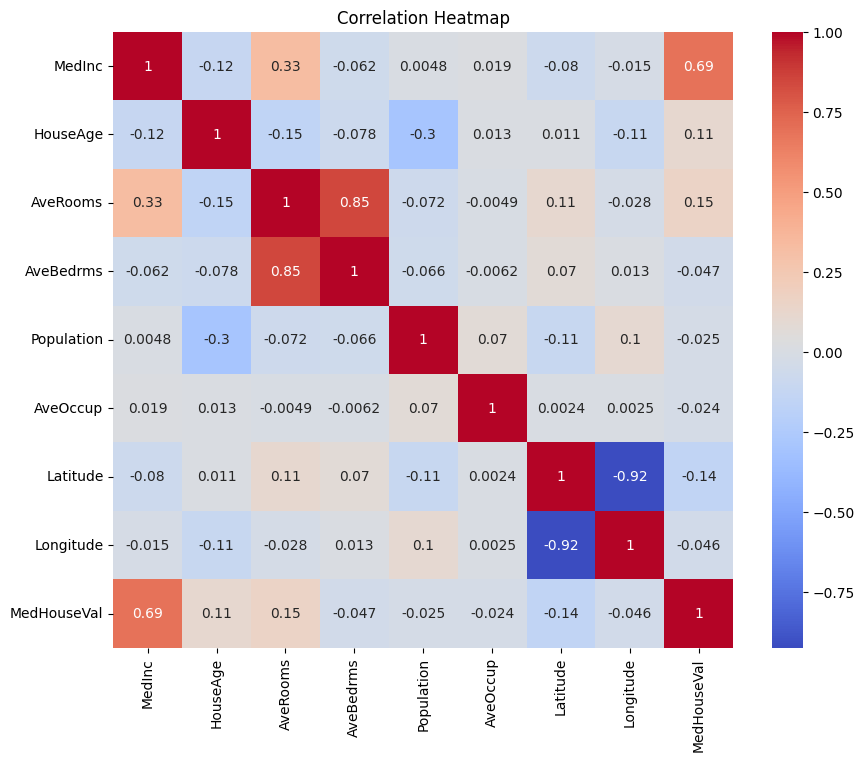

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### 3.5 Pairplot of Key Features

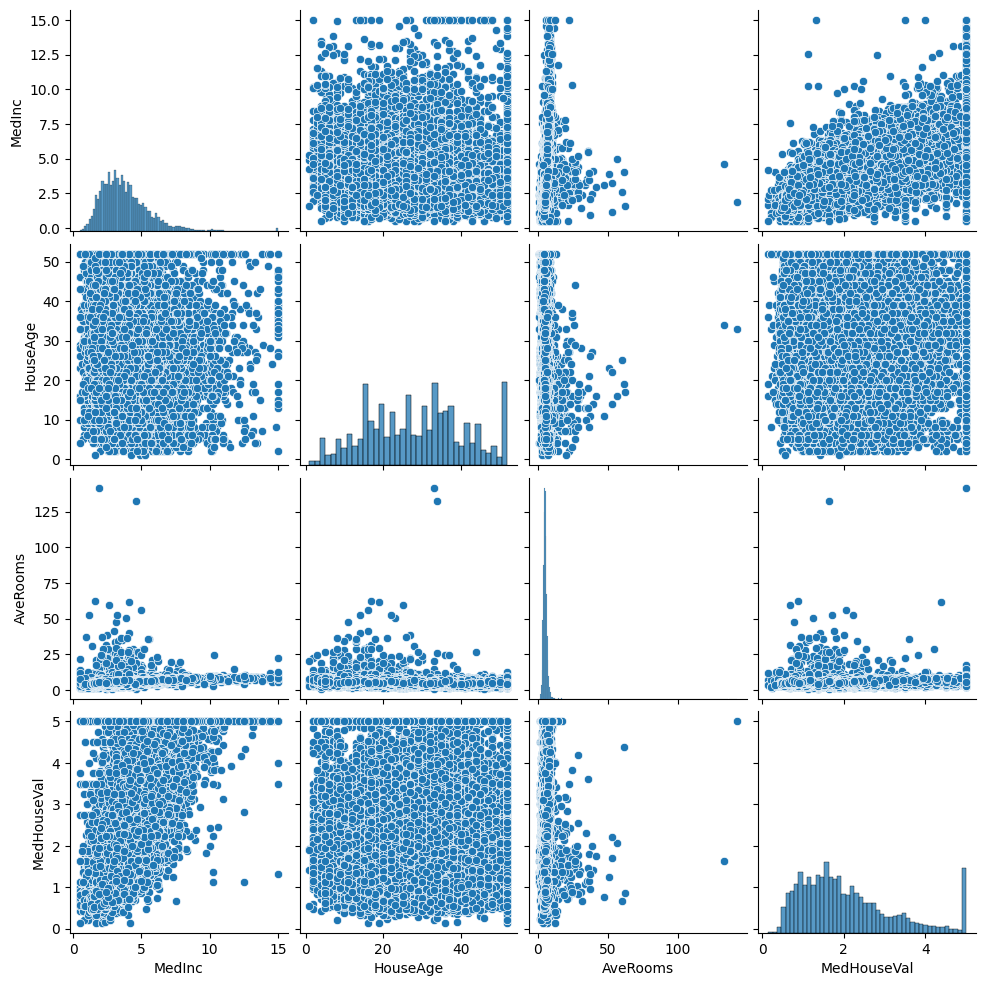

In [ ]:
sns.pairplot(df[["MedInc","HouseAge","AveRooms","MedHouseVal"]])
plt.show()

## 4. Feature Selection & Train/Test Split

In [ ]:
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Features Shape: (20640, 8)
Target Shape: (20640,)
Training Data: (16512, 8)
Testing Data: (4128, 8)


## 5. Model Training

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)
print("Model Training Completed")
#Generate predictions
y_pred = model.predict(X_test)
y_pred[:5]

Model Training Completed


array([0.71912284, 1.76401657, 2.70965883, 2.83892593, 2.60465725])

## 6. Model Evaluation

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("Mean Absolute Error :", round(mae,3))
print("Root Mean Squared Error :", round(rmse,3))
print("R² Score :", round(r2,3))

Mean Absolute Error : 0.533
Root Mean Squared Error : 0.746
R² Score : 0.576


## 7. Result Plots
### 7.1 Actual vs Predicted

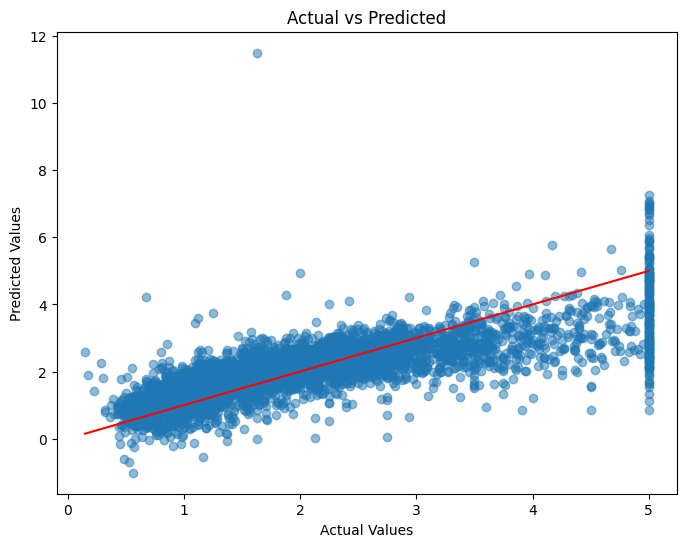

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(y_test,y_pred,alpha=0.5)
plt.plot([min(y_test), max(y_test)],[min(y_test), max(y_test)],color="red")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

### 7.2 Residual Analysis

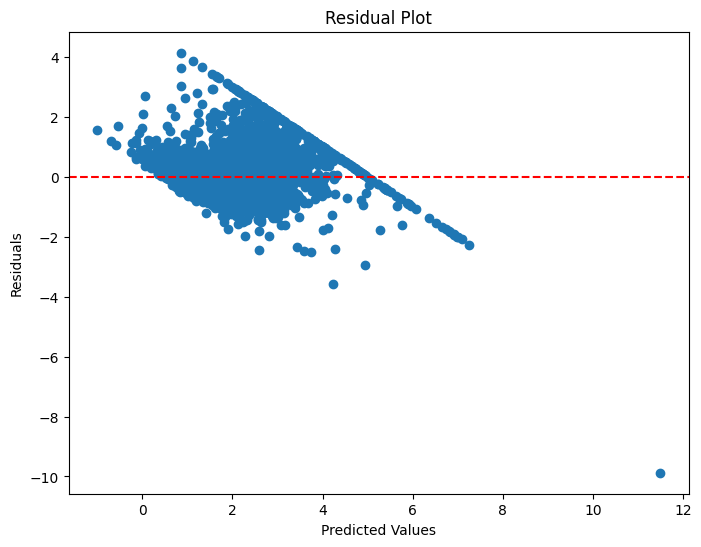

In [ ]:
residuals = y_test - y_pred
plt.figure(figsize=(8,6))
plt.scatter(y_pred,residuals)
plt.axhline(y=0,color="red",linestyle="--")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

### 7.3 Feature Importance (Coefficients)

In [ ]:
coefficients = pd.DataFrame({"Feature": X.columns,"Coefficient": model.coef_})
coefficients.sort_values(by="Coefficient",ascending=False)

,Feature,Coefficient
3,AveBedrms,0.7831
0,MedInc,0.4487
1,HouseAge,0.0097
4,Population,-0.0000
5,AveOccup,-0.0035
2,AveRooms,-0.1233
6,Latitude,-0.4198
7,Longitude,-0.4337


## 8. Save Model

In [ ]:
with open("house_price_model.pkl", "wb") as file:
    pickle.dump(model, file)
print("Model Saved Successfully")

Model Saved Successfully


Conclusion

1. Loaded and analyzed the California Housing Dataset.
2. Performed Exploratory Data Analysis (EDA).
3. Trained a Linear Regression model.
4. Evaluated the model using MAE, RMSE and R² Score.
5. Visualized predictions and residuals.
6. Saved the trained model for future predictions.

Future Improvements:
- Random Forest Regressor
- XGBoost Regressor
- Hyperparameter Tuning
- Feature Engineering